# 📉 Customer Churn Prediction — Full ML Pipeline
**Dataset:** Telco Customer Churn (IBM Watson)  
**Goal:** Predict which customers are likely to churn and understand the key drivers.

---
## Pipeline Overview
1. Data Loading & Inspection
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Model Training & Comparison
5. Evaluation & Interpretation
6. Feature Importance & Business Insights

## 1. 📦 Imports & Setup

In [4]:
!pip install pandas numpy matplotlib seaborn scikit-learn

  Using cached pandas-3.0.1-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.2-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp314-cp314-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp314-cp314-win_amd64.whl.metadata (6.4 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 9.9/9.9 MB 51.5 MB/s  0:00:00
   --

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay, RocCurveDisplay
)

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
CHURN_PALETTE = {'No': '#4C9BE8', 'Yes': '#E85C5C'}

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


## 2. 📂 Data Loading & Inspection

In [6]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [8]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


## 3. 🔍 Exploratory Data Analysis (EDA)

### 3.1 Churn Distribution

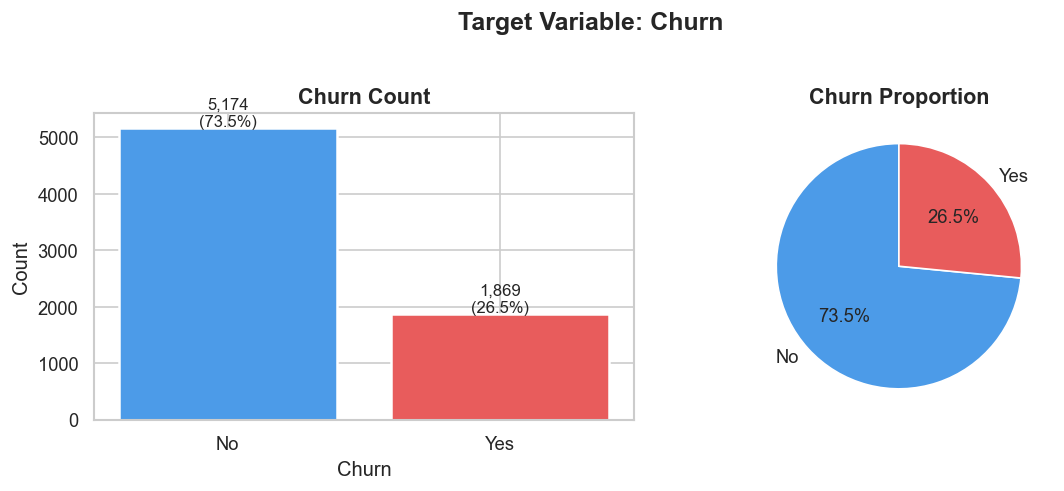


⚠️  Class imbalance: 26.5% churned — will use stratified splits & ROC-AUC as primary metric


In [9]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(churn_counts.index, churn_counts.values,
            color=[CHURN_PALETTE[k] for k in churn_counts.index], edgecolor='white', linewidth=1.5)
axes[0].set_title('Churn Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
for i, (v, p) in enumerate(zip(churn_counts.values, churn_pct.values)):
    axes[0].text(i, v + 30, f'{v:,}\n({p:.1f}%)', ha='center', fontsize=10)

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index,
            colors=[CHURN_PALETTE[k] for k in churn_counts.index],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Churn Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Churn', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f'\n⚠️  Class imbalance: {churn_pct["Yes"]:.1f}% churned — will use stratified splits & ROC-AUC as primary metric')

### 3.2 Numerical Features vs Churn

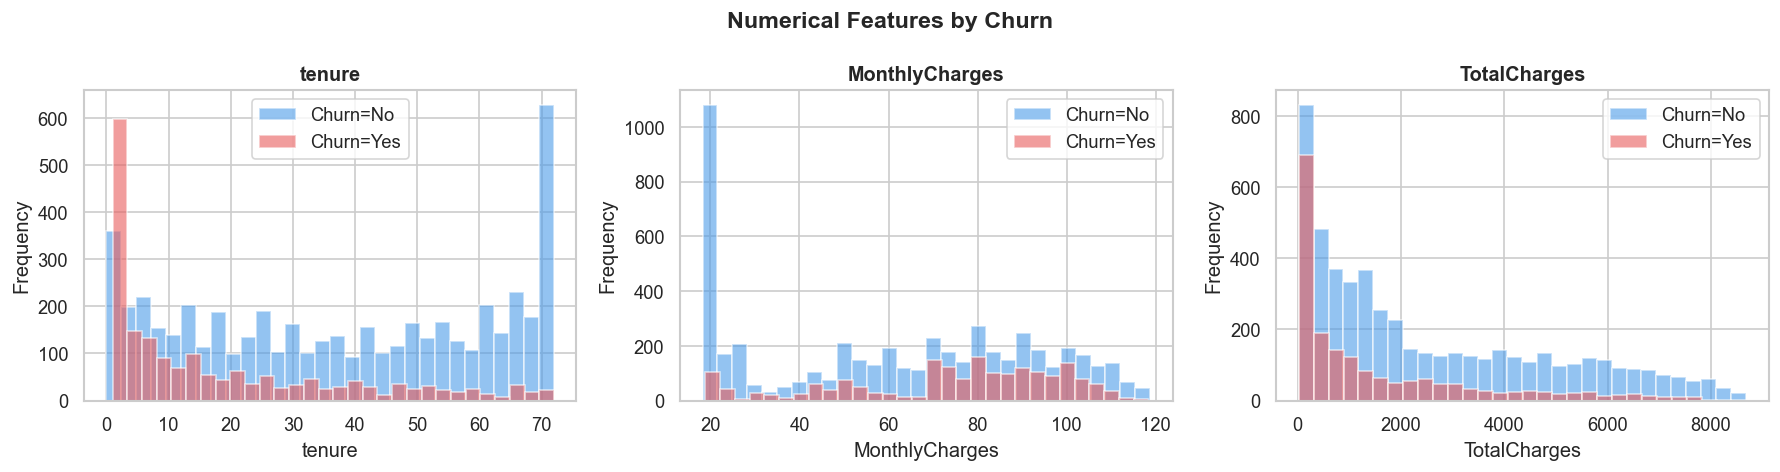

In [10]:
# Fix TotalCharges (whitespace strings → NaN → fill with 0)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, num_cols):
    for churn_val, color in CHURN_PALETTE.items():
        subset = df[df['Churn'] == churn_val][col]
        ax.hist(subset, bins=30, alpha=0.6, color=color, label=f'Churn={churn_val}', edgecolor='white')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Numerical Features by Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 Categorical Features vs Churn

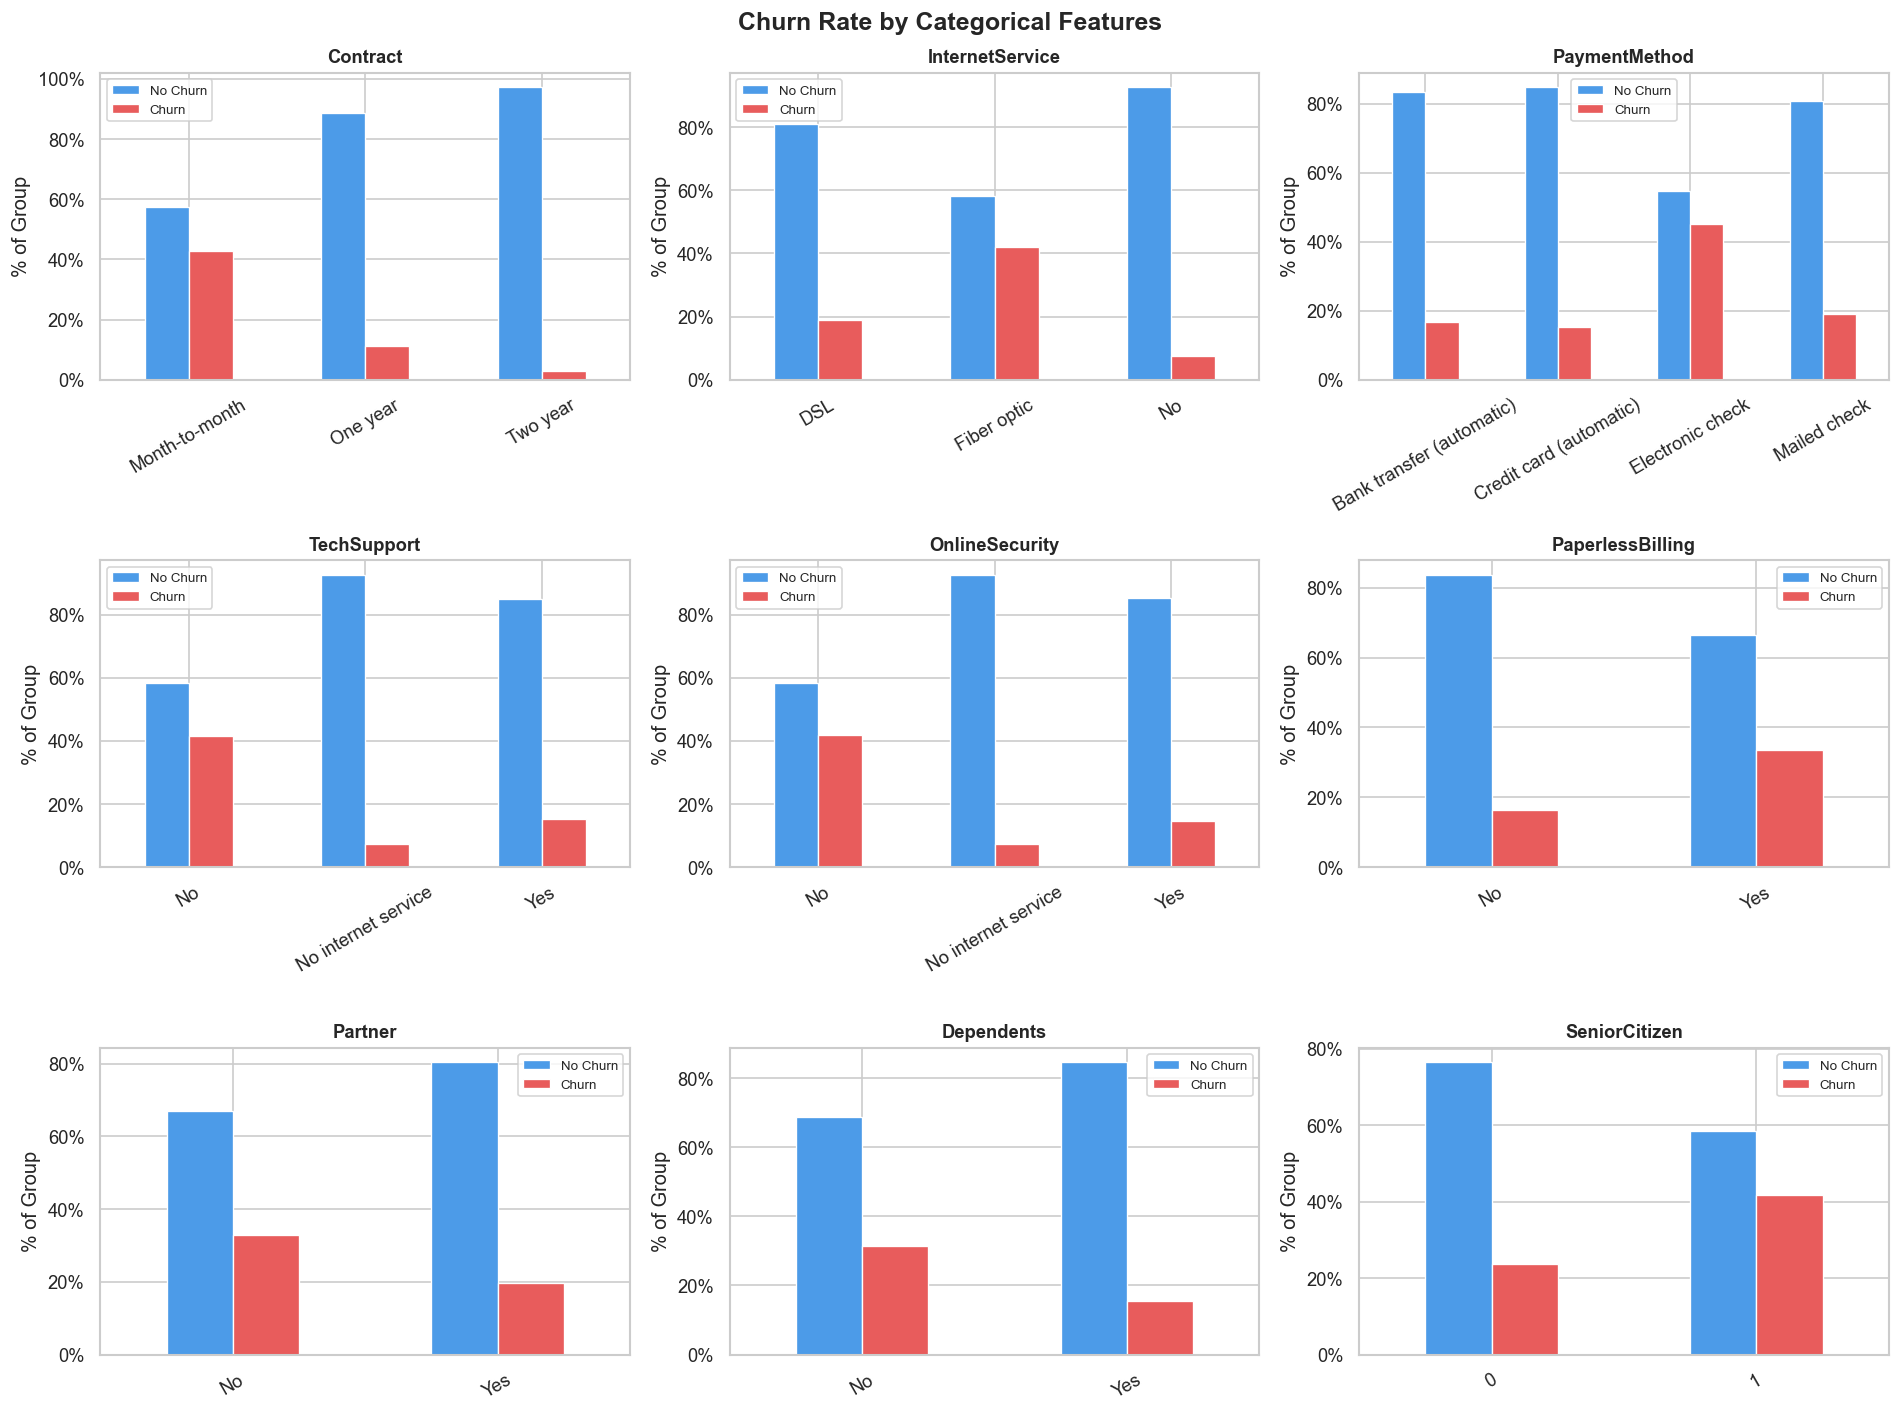

In [11]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod',
            'TechSupport', 'OnlineSecurity', 'PaperlessBilling',
            'Partner', 'Dependents', 'SeniorCitizen']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    ct = df.groupby([col, 'Churn']).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', ax=ax, color=[CHURN_PALETTE['No'], CHURN_PALETTE['Yes']],
                edgecolor='white', linewidth=0.8)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('% of Group')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(['No Churn', 'Churn'], fontsize=8)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.suptitle('Churn Rate by Categorical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Correlation Heatmap

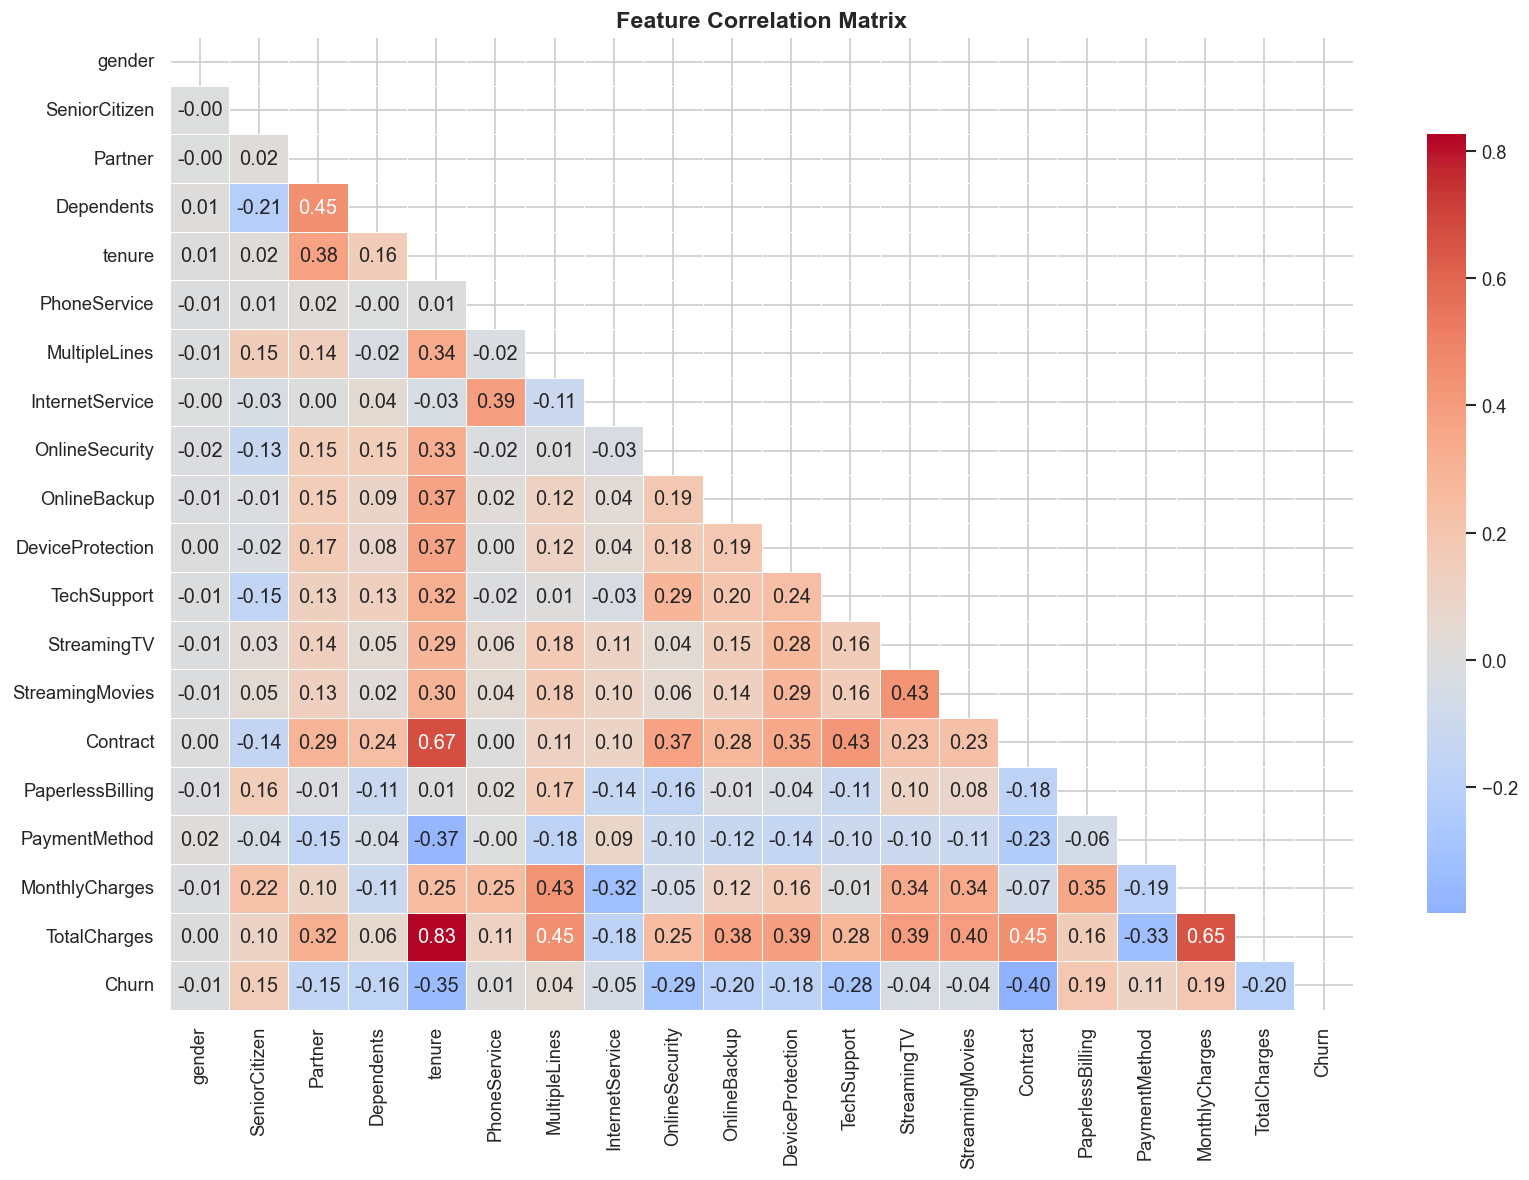

In [12]:
df_encoded_corr = df.copy()
for col in df_encoded_corr.select_dtypes(include='object').columns:
    df_encoded_corr[col] = LabelEncoder().fit_transform(df_encoded_corr[col].astype(str))

corr = df_encoded_corr.drop(columns=['customerID']).corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. 🛠️ Data Preprocessing

In [18]:
# Drop irrelevant column
df_model = df.drop(columns=['customerID'])

# Fix TotalCharges — blank strings become NaN, fill with 0
df_model['TotalCharges'] = pd.to_numeric(df_model['TotalCharges'].astype(str).str.strip(), errors='coerce')
df_model['TotalCharges'].fillna(0, inplace=True)

# Encode target
df_model['Churn'] = (df_model['Churn'] == 'Yes').astype(int)

# Encode all remaining object columns
le = LabelEncoder()
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# ✅ Kill any remaining NaNs
df_model.fillna(df_model.median(numeric_only=True), inplace=True)

# Confirm zero NaNs before proceeding
assert df_model.isnull().sum().sum() == 0, "❌ Still has NaNs!"
print('✅ Zero NaNs confirmed:', df_model.isnull().sum().sum())
print(f'Shape: {df_model.shape}')
df_model.head()

✅ Zero NaNs confirmed: 0
Shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [19]:
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

# Stratified train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size : {X_train.shape[0]:,} ({y_train.mean()*100:.1f}% churn)')
print(f'Test size  : {X_test.shape[0]:,} ({y_test.mean()*100:.1f}% churn)')

Train size : 5,634 (26.5% churn)
Test size  : 1,409 (26.5% churn)


## 5. 🤖 Model Training & Cross-Validation

In [20]:
models = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()),
                                      ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    'Decision Tree':        DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=200, max_depth=10,
                                                   random_state=42, n_jobs=-1),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                       max_depth=4, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv,
                             scoring='roc_auc')  # ← removed n_jobs=-1
    cv_results[name] = scores
    print(f'{name:<25} ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}')

print('\n✅ Cross-validation complete')

Logistic Regression       ROC-AUC: 0.8446 ± 0.0118
Decision Tree             ROC-AUC: 0.8218 ± 0.0036
Random Forest             ROC-AUC: 0.8410 ± 0.0086
Gradient Boosting         ROC-AUC: 0.8442 ± 0.0110

✅ Cross-validation complete


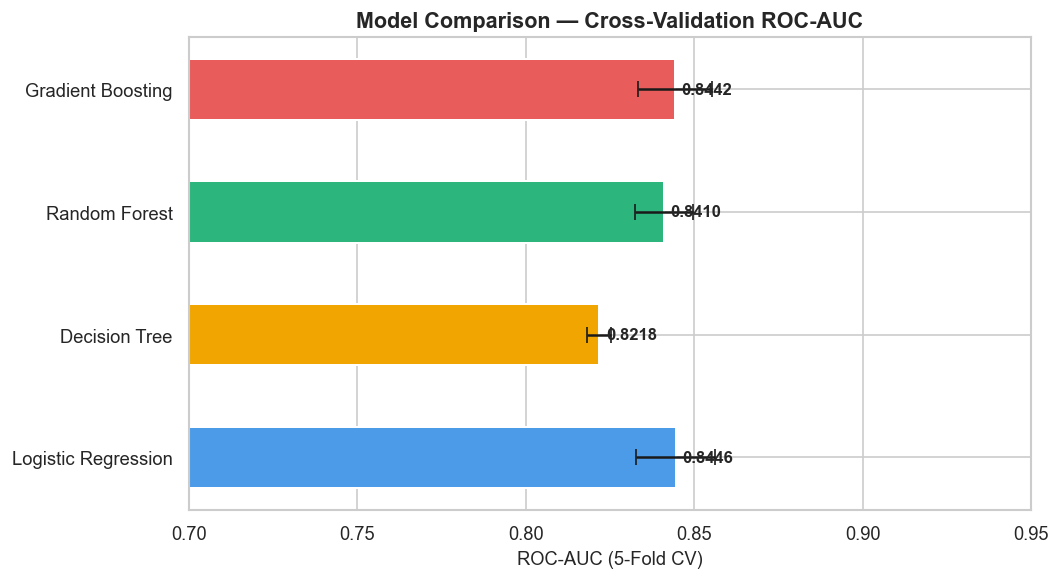

In [21]:
# Visualise CV results
fig, ax = plt.subplots(figsize=(9, 5))
names = list(cv_results.keys())
means = [cv_results[n].mean() for n in names]
stds  = [cv_results[n].std()  for n in names]
colors = ['#4C9BE8', '#F0A500', '#2CB67D', '#E85C5C']

bars = ax.barh(names, means, xerr=stds, color=colors, edgecolor='white',
               linewidth=1.2, capsize=5, height=0.5)
ax.set_xlabel('ROC-AUC (5-Fold CV)', fontsize=11)
ax.set_title('Model Comparison — Cross-Validation ROC-AUC', fontsize=13, fontweight='bold')
ax.set_xlim(0.7, 0.95)
for bar, mean in zip(bars, means):
    ax.text(mean + 0.002, bar.get_y() + bar.get_height()/2,
            f'{mean:.4f}', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. 📊 Evaluation on Test Set

In [23]:
!pip install jinja2

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)

   -------------------- ------------------- 1/2 [jinja2]
   ---------------------------------------- 2/2 [jinja2]



In [25]:
# Fit all models on full training set
trained = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained[name] = model

# Evaluate on test set
results = []
for name, model in trained.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    report  = classification_report(y_test, y_pred, output_dict=True)
    results.append({
        'Model':     name,
        'ROC-AUC':   round(roc_auc_score(y_test, y_proba), 4),
        'Accuracy':  round(report['accuracy'], 4),
        'Precision': round(report['1']['precision'], 4),
        'Recall':    round(report['1']['recall'], 4),
        'F1-Score':  round(report['1']['f1-score'], 4),
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df.style.background_gradient(cmap='Blues', subset=['ROC-AUC', 'F1-Score']).format(precision=4)

,Model,ROC-AUC,Accuracy,Precision,Recall,F1-Score
0,Gradient Boosting,0.8413,0.7999,0.6586,0.5107,0.5753
1,Logistic Regression,0.8403,0.7991,0.6426,0.5481,0.5916
2,Random Forest,0.8363,0.8006,0.6566,0.5214,0.5812
3,Decision Tree,0.8246,0.7842,0.6036,0.5455,0.5730


### 6.1 ROC Curves — All Models

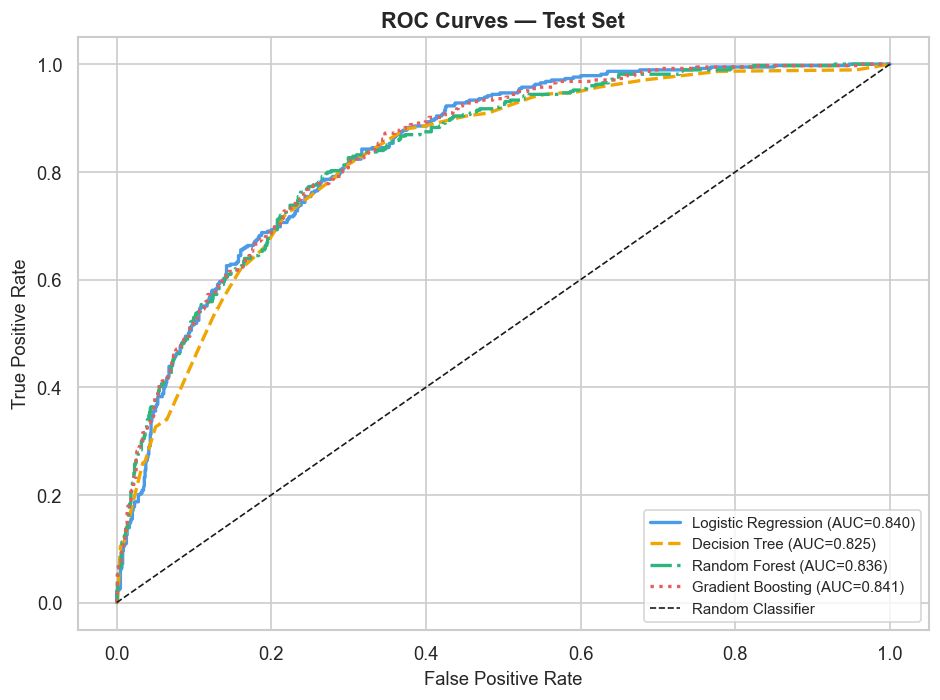

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))
line_styles = ['-', '--', '-.', ':']
line_colors = ['#4C9BE8', '#F0A500', '#2CB67D', '#E85C5C']

for (name, model), ls, lc in zip(trained.items(), line_styles, line_colors):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, linestyle=ls, color=lc, lw=2, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — Test Set', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

### 6.2 Confusion Matrix — Best Model

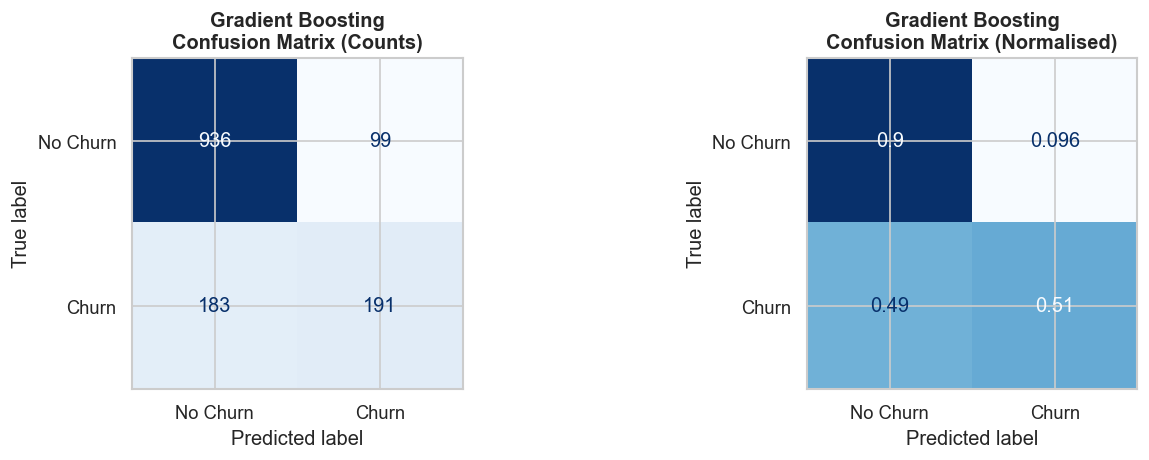


🏆 Best model: Gradient Boosting
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [27]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained[best_model_name]
y_pred_best = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw counts
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'{best_model_name}\nConfusion Matrix (Counts)', fontweight='bold')

# Normalised
cm_norm = confusion_matrix(y_test, y_pred_best, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['No Churn', 'Churn'])
disp2.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title(f'{best_model_name}\nConfusion Matrix (Normalised)', fontweight='bold')

plt.tight_layout()
plt.show()
print(f'\n🏆 Best model: {best_model_name}')
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))

## 7. 🔑 Feature Importance & Business Insights

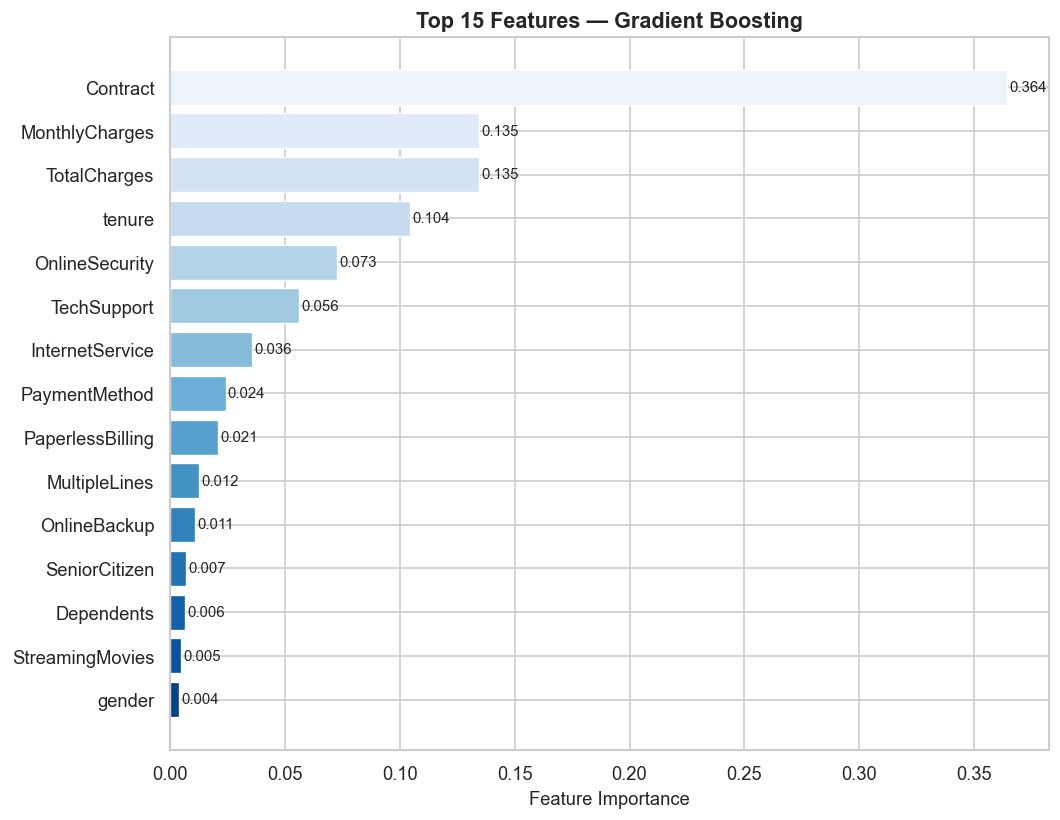

In [28]:
# Use best tree-based model for feature importance
tree_model_name = 'Gradient Boosting' if 'Gradient Boosting' in trained else 'Random Forest'
tree_model = trained[tree_model_name]
feature_model = tree_model  # Already fitted on X_train

importances = feature_model.feature_importances_
feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(feat_df['Feature'], feat_df['Importance'],
               color=sns.color_palette('Blues_r', len(feat_df)),
               edgecolor='white', linewidth=0.8)
ax.set_xlabel('Feature Importance', fontsize=11)
ax.set_title(f'Top 15 Features — {tree_model_name}', fontsize=13, fontweight='bold')
for bar, val in zip(bars, feat_df['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 8. 💡 Business Recommendations

Based on the feature importances and EDA, here are the key churn drivers and actionable recommendations:

| # | Finding | Recommended Action |
|---|---------|--------------------|
| 1 | **Short tenure** customers churn most | Implement onboarding loyalty programmes for new customers (months 1–6) |
| 2 | **Month-to-month contracts** have very high churn | Offer incentives (discounts, upgrades) to migrate customers to annual contracts |
| 3 | **High monthly charges** correlate with churn | Introduce tiered pricing or bundle discounts to reduce perceived cost |
| 4 | **No OnlineSecurity / TechSupport** drives churn | Bundle security/support add-ons into standard plans |
| 5 | **Fibre Optic** customers churn more despite higher spend | Investigate service quality issues with fibre customers |
| 6 | **Electronic check** payers churn more | Promote automatic payment methods with small incentives |
| 7 | **Senior citizens** are higher-risk | Create dedicated retention outreach for senior segment |

## 9. 💾 Save Best Model

In [29]:
import pickle

best_model_name = results_df.iloc[0]['Model']
best_model = trained[best_model_name]

with open('best_churn_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(f'✅ Saved: best_churn_model.pkl ({best_model_name})')
print(f'   Test ROC-AUC: {results_df.iloc[0]["ROC-AUC"]}')

# Example prediction
sample = X_test.iloc[:3]
probs = best_model.predict_proba(sample)[:, 1]
preds = best_model.predict(sample)
pd.DataFrame({'ChurnProbability': probs.round(3), 'Prediction': ['Churn' if p else 'No Churn' for p in preds]})

✅ Saved: best_churn_model.pkl (Gradient Boosting)
   Test ROC-AUC: 0.8413


,ChurnProbability,Prediction
0,0.019,No Churn
1,0.841,Churn
2,0.072,No Churn
